In [5]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import geopandas as gpd
import shapely
from shapely.ops import snap, unary_union
from shapely.geometry.polygon import Polygon
from shapely.geometry.multipolygon import MultiPolygon
import plotly.express as px

pd.options.display.float_format = '{:.2f}'.format# отображает числа с плавающей запятой с двумя знаками после запятой,
#необходимо сделать чтобы избежать экспоненциальную форму записи

In [104]:
df=pd.read_excel('rsmp_11.02.2025.xlsx',header=2)
df['Наименование / ФИО']=df['Наименование / ФИО'].str.replace('ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ','')\
.str.replace('()','')
df['Город']=df['Город'].str.replace('г ','')

/opt/anaconda3/envs/env1/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [13]:
count_interested_companies=1000#выборка из компаний которую мы хотим получить

In [ ]:
def send_request(url: str):
    return requests.get(
        url,
        headers=headers,
    )

In [9]:
def take_data(inn: int):
    
    try:
        url = f'https://bo.nalog.ru/advanced-search/organizations/search?query={inn}&page=0&size=20'
        r = send_request(url)
        org_id = r.json()['content'][0]['id']
        Dict={}
     
        time.sleep(3)
        r = send_request(f'https://bo.nalog.ru/nbo/organizations/{org_id}/bfo/')

        for data in r.json():
            try:
                Dict['ИНН']=inn
                Dict[(data['period'])] = data['correction']['financialResult']['current2400']
            except:
                pass
        return Dict
    
    except:
        pass


In [14]:
companies_mass=[]
for inn in df.iloc[0:count_interested_companies, df.columns.get_loc('ИНН')]:#указываем диапазон значений данные которых хотим получить 
    company={}
    try:
        company= take_data(inn)
        
        if(company):
            companies_mass.append(company)
            
    except:
        pass

In [17]:
def compound_mass(companies):
    final_dict={'ИНН':[],'2020':[],'2021':[],'2022':[],'2023':[]}
    
    fields=['ИНН','2023','2022','2021','2020']
    
    for company in companies:
        for field in fields:
            if field in company.keys():
                final_dict[field].append(company[field])
            else:
                final_dict[field].append(None)

    return final_dict


In [22]:
companies=pd.DataFrame(compound_mass(companies_mass))

In [86]:
#посчитаем на сколько изменилась чистая прибыль компании за 3года (2021,2022,2023)
def calculate_profit_growth(df:pd.DataFrame):
    profit=[]
    for i in range(df.shape[0]):
        series = df.iloc[i]
        if series['2023'] and series['2021']:
            profit.append((series['2023']*100/series['2021'])-100)
    return profit

In [90]:
companies['изменение прибыли за 3года(%)']=pd.Series(calculate_profit_growth(companies))

In [31]:
max=companies['изменение прибыли за 3года(%)'].max()
min=companies['изменение прибыли за 3года(%)'].min()
print(max,min)

139105.26315789475 -1519021.4285714286


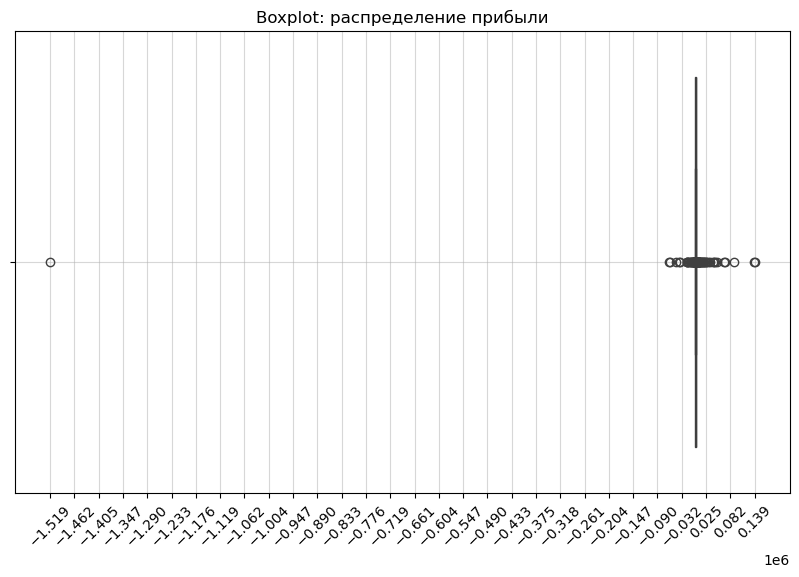

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=list(companies['изменение прибыли за 3года(%)'].dropna()))
plt.title("Boxplot: распределение прибыли")
plt.xticks(np.linspace(min, max,num=30, dtype=int), rotation=45)
plt.grid(alpha=0.5)
plt.show()

In [ ]:
# по графику "ящик с усами" можно сделать след вывод о данных
#1) есть много выбросов которыу мешают оценить данные
#2) усы не длинные то есть данные сконцентрированы ближе к центру, или же мы не можем их грамотно оченить так как очень много выбросов
#3) можно сделать вывод что для дальнейшего изучения данные необходимо их почистить от выбросов 
#выбросы будем чистить по формулам Q3 + 1.5 * IQR(верхняя граница) и (Q1 - 1.5 * IQR)(нижнаяя граница)

In [52]:
Q3=np.quantile(list(companies['изменение прибыли за 3года(%)'].dropna()),0.75)
Q1=np.quantile(list(companies['изменение прибыли за 3года(%)'].dropna()),0.25)
IQR=Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [113]:
# Фильтруем DataFrame от выбросов
df_without_emissions = companies.query(f" `изменение прибыли за 3года(%)` <= {upper_bound} and `изменение прибыли за 3года(%)`>= {lower_bound} ")

In [124]:
#кол-во бинов определим по формуле 1+log_2(N) N=len(df_without_emissions)
bins = np.quantile([df_without_emissions['изменение прибыли за 3года(%)'].dropna()], np.linspace(0, 1, 25+ 1))
min=df_without_emissions['изменение прибыли за 3года(%)'].min()
max=df_without_emissions['изменение прибыли за 3года(%)'].max()

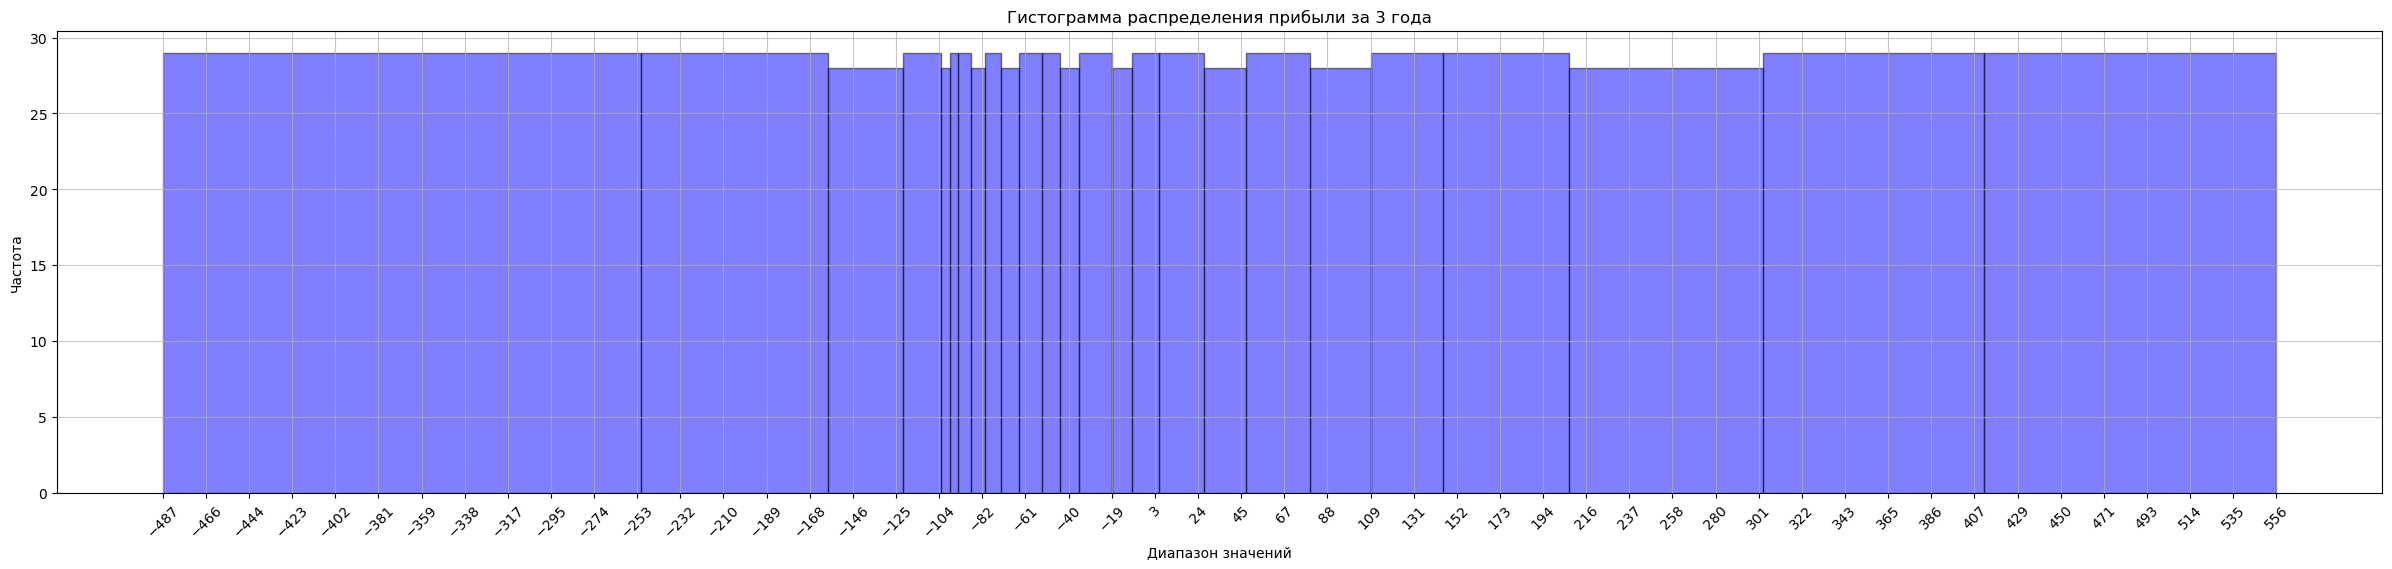

In [125]:
plt.figure(figsize=(30, 6))
plt.hist([df_without_emissions['изменение прибыли за 3года(%)'].dropna()], bins=bins,color='blue',alpha=0.5,edgecolor='black')
plt.xticks(np.linspace(min, max,num=50), rotation=45)
plt.xlabel("Диапазон значений")
plt.ylabel("Частота")
plt.title("Гистограмма распределения прибыли за 3 года")
plt.grid(alpha=0.7)
plt.show()

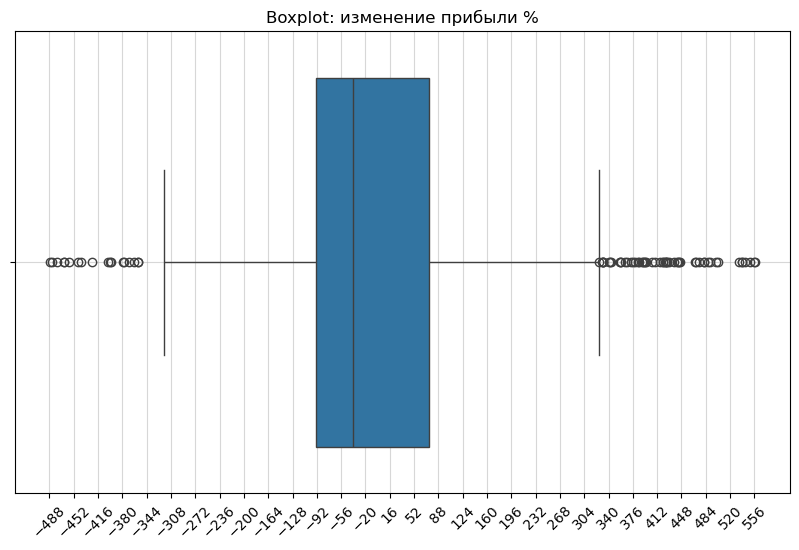

In [117]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=list(df_without_emissions['изменение прибыли за 3года(%)']))
plt.title("Boxplot: изменение прибыли %")
plt.xticks(np.linspace(min, max,num=30, dtype=int), rotation=45)
plt.grid(alpha=0.5)
plt.show()

In [406]:
# по построенным графиком можно сделат след выводы

# судя по гистограмме у нас очень большой разброс значений и  сущесвуют компании,которые как  увеличили прибыль в разы,
# так и уменьшили прибыль и их большенство, то есть в данных есть сильные колбебания,
# которые свидетельсвуют о неустойчивости рынка и рисков для компаний

# Все  интервалы имеют плюс-минус одинаковую частоту , что свидетельсвует об отсутсвии выраженных тенденций к определенным значениям.
# Что может говорить о том,что компании придерживаются разных стратегий в ведении бизнеса.
 
# Отрицательные значения более склоны к центру чем положительные это так же можно увидет и по графику ящик с усами
# где медиана расположена между[-56;-20] то есть с 50% вероятностью значение прибыли у компании 
#отрицательное,так же наблюдается левостроння   ассиметрия,
# у компаний с  отрицательным ростом выбросов наблюдается меньше,то есть компаний,у которых 
#убыток намного больше чем у других немного 

In [60]:
#грузим данные регионов и городов россии 
gdf = gpd.read_file("russia_regions.geojson")
gdf_cities=gpd.read_file("russia_cities.geojson")
gdf = gdf.to_crs('EPSG:32646')
gdf_cities= gdf_cities.to_crs('EPSG:32646')

In [98]:
#нанесем на крату топ 500 компаний по выручке за 2023(или хотя бы постарамся)
companies_sorted=companies.sort_values(by='2023',ascending=False).iloc[:500]
merged_df=companies_sorted.merge(df,left_on='ИНН',right_on='ИНН')['Город']

In [111]:
coordinates_company=gdf_cities.merge(merged_df,left_on='city',right_on='Город')[['city','geometry']]

<Axes: >

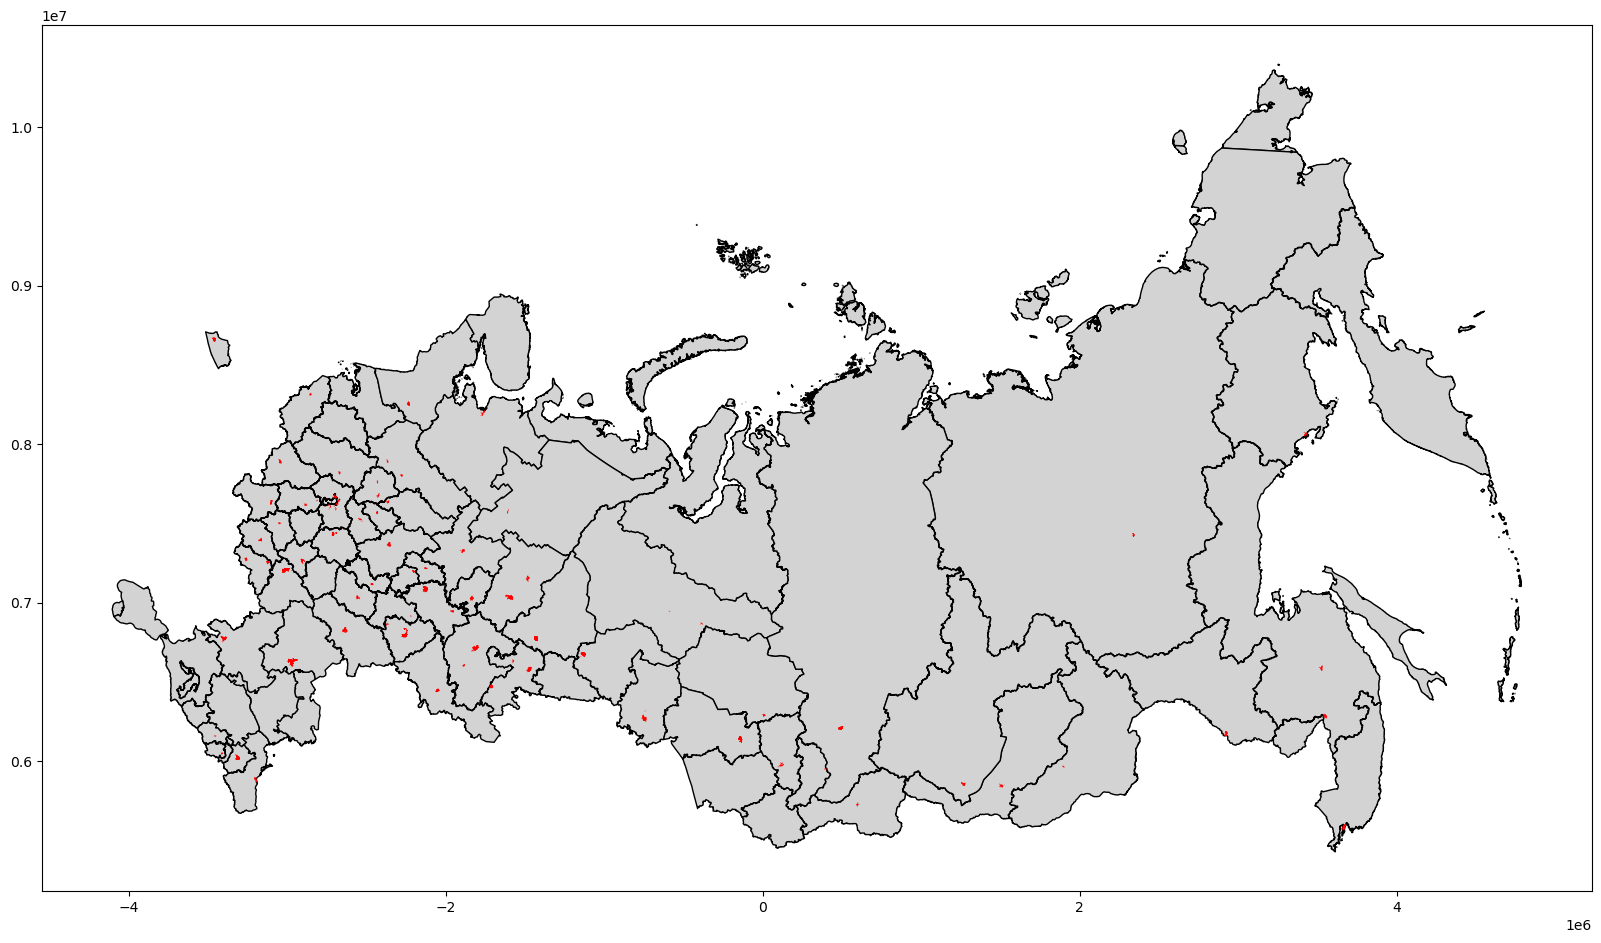

In [112]:
fig, ax = plt.subplots(figsize=(20, 20))  # Создаем фигуру и оси

# Наносим базовую карту
gdf.plot(ax=ax, color='lightgray', edgecolor='black')

# Наносим города
coordinates_company.plot(ax=ax, marker='*', color='red', markersize=1000)

In [ ]:
#по карте видно ,что компании имеющие максимальную прибыль расположены в западной части страны,
# большинство наиболее прибыльных компаний сосредоточено в столице (Москва) 
# и других крупных городах, таких как Санкт-Петербург, Екатеринбург, Новосибирск и Казань.
#Так же это можно обусловить тем что западная часть страны является исторически более  развитой в экономическом плане что привлекает бизнес

# Меньшая плотность прибыльных компаний в Сибири и на Дальнем Востоке – несмотря 
# на наличие некоторых точек в этих регионах, их значительно меньше. Это может быть 
# связано с низкой плотностью населения, сложными климатическими условиями и высокой стоимостью логистики.